# Step 6: Hosing with mixed boundary conditions

Does the AMOC respond differently to the same hosing when surface salinity is no longer restored? I repeat the step 4 experiments (0.1, 0.3 and 0.5 Sv for 200 years, then 300 years off) under mixed boundary conditions, and compare them with the restoring runs: how much the AMOC weakens, and whether it recovers.

The runs start from the end of the spin-up (year 2000), like `mixed_control` from step 5, which is their control. They were made with `scripts/run_hosing_set.sh mixed experiments/mixed_forcing ... skip_control`.

I load the libraries and shared functions, and set the paths and run names.

In [1]:
%matplotlib inline

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sys.path.append("../src")   # amoc_tools.py lives in the project's src/ folder
from amoc_tools import (read_grid, amoc_series, atlantic_streamfunction, output_iterations,
                        annual_field, STEPS_PER_YEAR)
from MITgcmutils import rdmds

RUNS = os.path.expanduser("~/mitgcm_runs/hosing")
HOSING = {"010": 0.1, "030": 0.3, "050": 0.5}
HOSING_END = 2200
AVERAGE_YEARS = 10                  # "end of hosing" = 2191-2200, "end of recovery" = 2491-2500
RECOVERED_WITHIN = 1.0              # I call a run "recovered" if it ends within 1 Sv of its control
COLORS = {"control": "k", "010": "tab:blue", "030": "tab:orange", "050": "tab:red"}
STRONGEST_VALID = "030"             # 0.3 Sv: the strongest mixed-BC run that stays numerically valid (see below)
FIG_DIR = "../figures"
DATA_DIR = "../data"

I read the grid and masks, and check every mixed-BC run. 'Ended normally' is not enough: the 0.5 Sv run printed 'Execution ended Normally' even though its fields became NaN (not a number) in model year 2090, after its free-surface solver blew up. So I also check that every annual-mean velocity value is a finite number.

In [2]:
grid = read_grid(os.path.join(RUNS, "spinup"), DATA_DIR)
for code in HOSING:
    for part in ["on", "off"]:
        name = f"mixed_hose{code}_{part}"
        ok = "Execution ended Normally" in open(os.path.join(RUNS, name, "output.txt")).read()
        its = output_iterations(os.path.join(RUNS, name), "vvel_annual")
        first_bad = None
        for it in its:
            if not np.all(np.isfinite(rdmds(os.path.join(RUNS, name, "vvel_annual"), it))):
                first_bad = it / STEPS_PER_YEAR
                break
        status = "all finite" if first_bad is None else f"NOT FINITE from model year {first_bad:.0f}"
        print(f"{name:20s} ended normally: {ok} | annual means: {len(its)} | {status}")
    print(f"   pickup at year 2200: {os.path.exists(os.path.join(RUNS, f'mixed_hose{code}_on', 'pickup.0000792000.data'))}")

mixed_hose010_on     ended normally: True | annual means: 200 | all finite


mixed_hose010_off    ended normally: True | annual means: 300 | all finite
   pickup at year 2200: True


mixed_hose030_on     ended normally: True | annual means: 200 | all finite


mixed_hose030_off    ended normally: True | annual means: 300 | all finite
   pickup at year 2200: True
mixed_hose050_on     ended normally: True | annual means: 200 | NOT FINITE from model year 2090
mixed_hose050_off    ended normally: True | annual means: 300 | NOT FINITE from model year 2201
   pickup at year 2200: True


I compute the AMOC index for the mixed-BC hosing runs (joining the on and off parts) and read the controls and the step 4 restoring runs from the CSV files saved earlier.

In [3]:
years, mixed_control = amoc_series([os.path.join(RUNS, "mixed_control")], grid)
mixed = {"control": mixed_control}
for code in HOSING:
    y, mixed[code] = amoc_series([os.path.join(RUNS, f"mixed_hose{code}_on"),
                                  os.path.join(RUNS, f"mixed_hose{code}_off")], grid)
    assert np.array_equal(y, years)

restore_table = np.genfromtxt(os.path.join(DATA_DIR, "amoc_index_restore.csv"), delimiter=",", names=True)
assert np.array_equal(restore_table["model_year"], years)
restore = {"control": restore_table["control_sv"]}
for code in HOSING:
    restore[code] = restore_table[f"hose{code}_sv"]

csv_path = os.path.join(DATA_DIR, "amoc_index_mixed.csv")
with open(csv_path, "w") as f:
    f.write("model_year,control_sv," + ",".join(f"hose{code}_sv" for code in HOSING) + "\n")
    for n in range(len(years)):
        values = [mixed["control"][n]] + [mixed[code][n] for code in HOSING]
        f.write(f"{years[n]:.0f}," + ",".join(f"{v:.4f}" for v in values) + "\n")
print("saved", csv_path)

saved ../data/amoc_index_mixed.csv


This figure puts the two sets side by side, on the same scale: restoring on the left, mixed boundary conditions on the right.

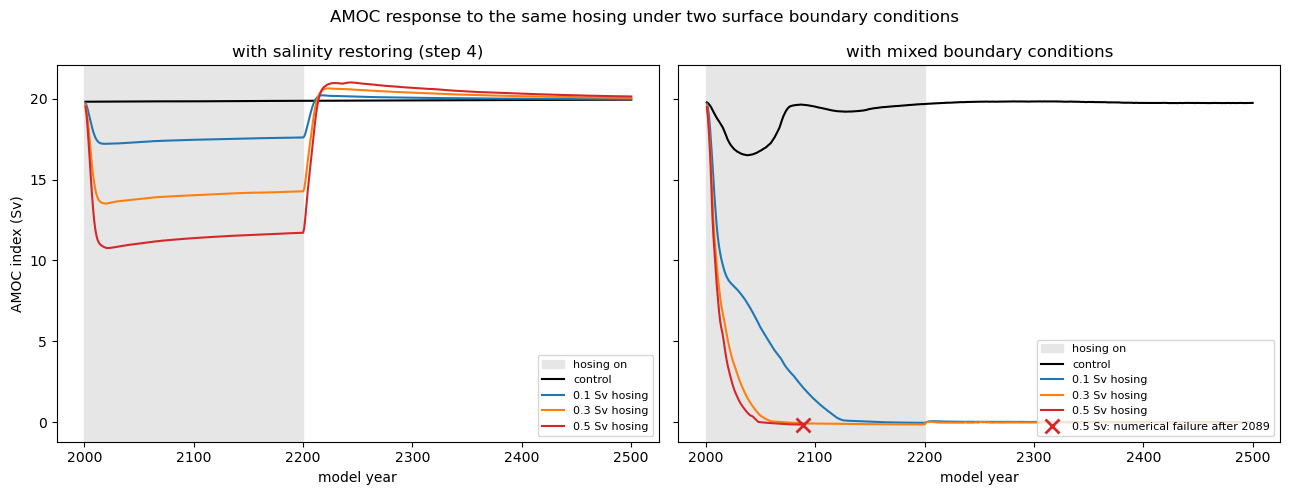

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, runs, title in [(axes[0], restore, "with salinity restoring (step 4)"),
                        (axes[1], mixed, "with mixed boundary conditions")]:
    ax.axvspan(2000, HOSING_END, color="0.9", label="hosing on")
    ax.plot(years, runs["control"], color=COLORS["control"], lw=1.5, label="control")
    for code, strength in HOSING.items():
        ax.plot(years, runs[code], color=COLORS[code], lw=1.5, label=f"{strength} Sv hosing")
        valid = np.isfinite(runs[code])
        if not np.all(valid):   # mark where a run stopped being valid
            ax.plot(years[valid][-1], runs[code][valid][-1], "x", color=COLORS[code], ms=10, mew=2,
                    label=f"{strength} Sv: numerical failure after {years[valid][-1]:.0f}")
    ax.set_xlabel("model year")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("AMOC index (Sv)")
fig.suptitle("AMOC response to the same hosing under two surface boundary conditions")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_amoc_restoring_vs_mixed.png"), dpi=150)
plt.show()

I summarise both sets the same way as in step 4: each run compared with its own control, at the end of hosing and at the end of recovery. For the 0.5 Sv mixed-BC run these windows fall after the numerical failure, so I report the failure year instead, and its lowest value before it.

In [5]:
def mean_over(series, last_year):
    keep = (years > last_year - AVERAGE_YEARS) & (years <= last_year)
    return series[keep].mean()

summary = {}
print(f"{'set':8s} {'hosing':>7s} {'end of hosing':>14s} {'change':>9s} {'change':>8s} {'minimum (year)':>16s} {'end of recovery':>16s} {'change':>8s} {'recovered?':>11s}")
for label, runs in [("restore", restore), ("mixed", mixed)]:
    c_h = mean_over(runs["control"], HOSING_END)
    c_r = mean_over(runs["control"], years[-1])
    print(f"{label:8s} {'control':>7s} {c_h:11.2f} Sv {'':>9s} {'':>8s} {'':>16s} {c_r:13.2f} Sv")
    for code, strength in HOSING.items():
        valid = np.isfinite(runs[code])
        if not np.all(valid):
            last_ok = years[valid][-1]
            n_min = np.nanargmin(runs[code])
            summary[(label, code)] = None
            print(f"{label:8s} {strength:5.1f} Sv   numerical failure after model year {last_ok:.0f}; "
                  f"lowest value before it {runs[code][n_min]:.2f} Sv ({years[n_min]:.0f}), "
                  f"value in {last_ok:.0f}: {runs[code][valid][-1]:.2f} Sv")
            continue
        e_h = mean_over(runs[code], HOSING_END)
        e_r = mean_over(runs[code], years[-1])
        n_min = np.argmin(runs[code])
        recovered = abs(e_r - c_r) <= RECOVERED_WITHIN
        summary[(label, code)] = (e_h - c_h, e_r - c_r, recovered)
        print(f"{label:8s} {strength:5.1f} Sv {e_h:11.2f} Sv {e_h - c_h:+8.2f} {100 * (e_h - c_h) / c_h:+7.1f}% "
              f"{runs[code][n_min]:8.2f} ({years[n_min]:.0f}) {e_r:13.2f} Sv {e_r - c_r:+8.2f} {str(recovered):>11s}")

set       hosing  end of hosing    change   change   minimum (year)  end of recovery   change  recovered?
restore  control       19.87 Sv                                             19.94 Sv
restore    0.1 Sv       17.60 Sv    -2.27   -11.4%    17.21 (2018)         19.99 Sv    +0.04        True
restore    0.3 Sv       14.27 Sv    -5.60   -28.2%    13.52 (2020)         20.06 Sv    +0.11        True
restore    0.5 Sv       11.70 Sv    -8.17   -41.1%    10.77 (2021)         20.15 Sv    +0.20        True
mixed    control       19.66 Sv                                             19.74 Sv
mixed      0.1 Sv       -0.04 Sv   -19.70  -100.2%    -0.04 (2200)          0.00 Sv   -19.73       False
mixed      0.3 Sv       -0.14 Sv   -19.80  -100.7%    -0.14 (2199)         -0.02 Sv   -19.76       False
mixed      0.5 Sv   numerical failure after model year 2089; lowest value before it -0.15 Sv (2089), value in 2089: -0.15 Sv


Next, the strongest case in more detail. The 0.5 Sv mixed-BC run is not valid after 2089, so I use 0.3 Sv, the strongest run that is valid all the way through, for both boundary conditions, so the two are compared at the same strength. I average the annual surface salinity over 10-year windows and subtract the matching control. This function does that for one run and one window.

In [6]:
def mean_surface_salinity(run_dirs, last_year):
    """Mean surface salinity over the AVERAGE_YEARS ending at last_year, from one or more run folders."""
    total = np.zeros(grid["ocean"].shape)
    count = 0
    for run_dir in run_dirs:
        for it in output_iterations(run_dir, "surf_ts_annual"):
            year = it / STEPS_PER_YEAR
            if last_year - AVERAGE_YEARS < year <= last_year:
                total += annual_field(run_dir, "surf_ts_annual", "SALT", it)
                count += 1
    return total / count

def hosing_dirs(label, code):
    return [os.path.join(RUNS, f"{label}_hose{code}_on"), os.path.join(RUNS, f"{label}_hose{code}_off")]

def region_mean(field, mask):
    return np.sum(field * grid["rac"] * mask) / np.sum(grid["rac"] * mask)

dsss = {}
for label in ["restore", "mixed"]:
    control_dir = [os.path.join(RUNS, f"{label}_control")]
    for last_year in [HOSING_END, int(years[-1])]:
        dsss[(label, last_year)] = (mean_surface_salinity(hosing_dirs(label, STRONGEST_VALID), last_year)
                                    - mean_surface_salinity(control_dir, last_year))
        print(f"{label:8s} {HOSING[STRONGEST_VALID]} Sv, years {last_year - AVERAGE_YEARS + 1}-{last_year}: surface salinity change "
              f"in the hosing region {region_mean(dsss[(label, last_year)], grid['region']):+.3f} g/kg, "
              f"Atlantic {region_mean(dsss[(label, last_year)], grid['atlantic']):+.3f} g/kg")

restore  0.3 Sv, years 2191-2200: surface salinity change in the hosing region -0.304 g/kg, Atlantic -0.037 g/kg
restore  0.3 Sv, years 2491-2500: surface salinity change in the hosing region -0.001 g/kg, Atlantic -0.000 g/kg
mixed    0.3 Sv, years 2191-2200: surface salinity change in the hosing region -5.729 g/kg, Atlantic -3.013 g/kg


mixed    0.3 Sv, years 2491-2500: surface salinity change in the hosing region -2.794 g/kg, Atlantic -1.534 g/kg


This figure maps the change in North Atlantic surface salinity for the 0.3 Sv runs (hosing run minus its control) at the end of hosing and at the end of recovery, for both boundary conditions.

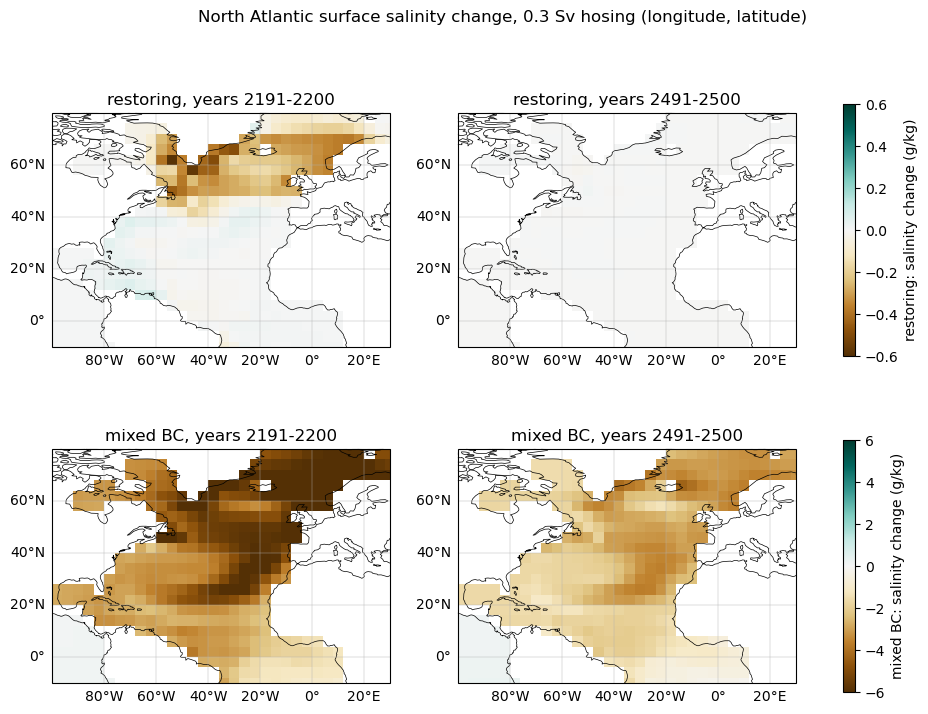

In [7]:
lon_edges = np.arange(0, 361, 4.0)
lat_edges = np.arange(-80, 81, 4.0)
LIMITS = {"restore": 0.6, "mixed": 6.0}   # the changes differ ten-fold, so each row gets its own colour scale
fig, axes = plt.subplots(2, 2, figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=-30)})
for row, label in enumerate(["restore", "mixed"]):
    for col, last_year in enumerate([HOSING_END, int(years[-1])]):
        ax = axes[row, col]
        field = np.where(grid["ocean"], dsss[(label, last_year)], np.nan)
        mesh = ax.pcolormesh(lon_edges, lat_edges, field, cmap="BrBG", vmin=-LIMITS[label], vmax=LIMITS[label],
                             transform=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.set_extent([-100, 30, -10, 80], crs=ccrs.PlateCarree())
        gl = ax.gridlines(draw_labels=True, linewidth=0.3)
        gl.top_labels = False
        gl.right_labels = False
        name = "restoring" if label == "restore" else "mixed BC"
        ax.set_title(f"{name}, years {last_year - AVERAGE_YEARS + 1}-{last_year}")
    fig.colorbar(mesh, ax=axes[row, :], shrink=0.9, label=f"{name}: salinity change (g/kg)")
fig.suptitle(f"North Atlantic surface salinity change, {HOSING[STRONGEST_VALID]} Sv hosing (longitude, latitude)")
fig.savefig(os.path.join(FIG_DIR, f"06_sss_change_{STRONGEST_VALID}.png"), dpi=150, bbox_inches="tight")
plt.show()

Now the Atlantic overturning streamfunction for the 0.3 Sv mixed-BC run at the end of hosing and at the end of recovery, next to its control at the end of the run. Each panel is computed from the velocity averaged over 10 years.

mixed control, years 2491-2500: maximum north of 20°N below 500 m = 19.74 Sv
0.3 Sv mixed BC, end of hosing (2191-2200): maximum north of 20°N below 500 m = 0.00 Sv
0.3 Sv mixed BC, end of recovery (2491-2500): maximum north of 20°N below 500 m = -0.01 Sv


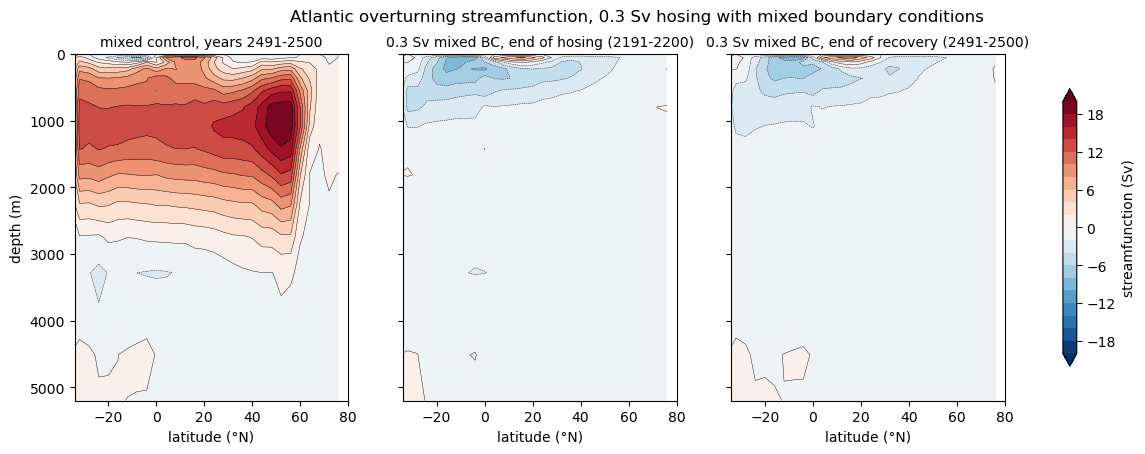

In [8]:
def mean_streamfunction(run_dirs, last_year):
    v_sum = None
    count = 0
    for run_dir in run_dirs:
        for it in output_iterations(run_dir, "vvel_annual"):
            year = it / STEPS_PER_YEAR
            if last_year - AVERAGE_YEARS < year <= last_year:
                v = rdmds(os.path.join(run_dir, "vvel_annual"), it)
                v_sum = v if v_sum is None else v_sum + v
                count += 1
    return atlantic_streamfunction(v_sum / count, grid)

panels = [("mixed control, years 2491-2500", mean_streamfunction([os.path.join(RUNS, "mixed_control")], int(years[-1]))),
          (f"{HOSING[STRONGEST_VALID]} Sv mixed BC, end of hosing (2191-2200)", mean_streamfunction(hosing_dirs("mixed", STRONGEST_VALID), HOSING_END)),
          (f"{HOSING[STRONGEST_VALID]} Sv mixed BC, end of recovery (2491-2500)", mean_streamfunction(hosing_dirs("mixed", STRONGEST_VALID), int(years[-1])))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
levels = np.arange(-20, 21, 2)
for ax, (title, psi) in zip(axes, panels):
    cs = ax.contourf(grid["lat_v"], grid["z_interface"], psi, levels=levels, cmap="RdBu_r", extend="both")
    ax.contour(grid["lat_v"], grid["z_interface"], psi, levels=levels, colors="k", linewidths=0.3)
    ax.set_xlim(-34, 80)
    ax.set_xlabel("latitude (°N)")
    ax.set_title(title, fontsize=10)
    print(f"{title}: maximum north of 20°N below 500 m = "
          f"{psi[grid['z_interface'] >= 500][:, grid['lat_v'] >= 20].max():.2f} Sv")
axes[0].invert_yaxis()
axes[0].set_ylabel("depth (m)")
fig.colorbar(cs, ax=axes, shrink=0.8, label="streamfunction (Sv)")
fig.suptitle(f"Atlantic overturning streamfunction, {HOSING[STRONGEST_VALID]} Sv hosing with mixed boundary conditions")
fig.savefig(os.path.join(FIG_DIR, f"06_streamfunction_mixed_{STRONGEST_VALID}.png"), dpi=150, bbox_inches="tight")
plt.show()

Finally, a promise from step 4: the restoring runs overshot after the hosing stopped. One idea was that salty water builds up in the subtropical Atlantic while the AMOC is weak, then moves north. I map the surface salinity change of the 0.5 Sv restoring run at the end of hosing and during the overshoot, to see whether the subtropics really are saltier.

restoring 0.5 Sv, years 2191-2200: subtropical Atlantic (10-40°N) surface salinity change +0.013 g/kg, hosing region -0.528 g/kg
restoring 0.5 Sv, years 2221-2230: subtropical Atlantic (10-40°N) surface salinity change +0.008 g/kg, hosing region +0.001 g/kg


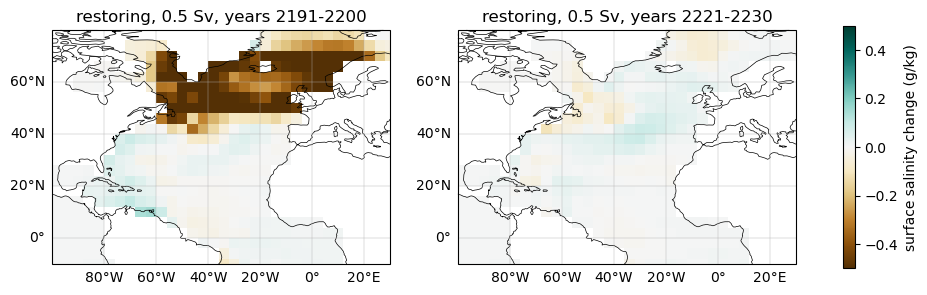

In [9]:
overshoot_years = [HOSING_END, 2230]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=-30)})
subtropics = grid["atlantic"] & (grid["yc"] >= 10) & (grid["yc"] <= 40)
for ax, last_year in zip(axes, overshoot_years):
    d = (mean_surface_salinity(hosing_dirs("restore", "050"), last_year)
         - mean_surface_salinity([os.path.join(RUNS, "restore_control")], last_year))
    print(f"restoring 0.5 Sv, years {last_year - AVERAGE_YEARS + 1}-{last_year}: subtropical Atlantic (10-40°N) "
          f"surface salinity change {region_mean(d, subtropics):+.3f} g/kg, hosing region {region_mean(d, grid['region']):+.3f} g/kg")
    mesh = ax.pcolormesh(lon_edges, lat_edges, np.where(grid["ocean"], d, np.nan), cmap="BrBG", vmin=-0.5, vmax=0.5,
                         transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([-100, 30, -10, 80], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels=True, linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(f"restoring, 0.5 Sv, years {last_year - AVERAGE_YEARS + 1}-{last_year}")
fig.colorbar(mesh, ax=axes, shrink=0.7, label="surface salinity change (g/kg)")
fig.savefig(os.path.join(FIG_DIR, "06_restoring_overshoot_sss.png"), dpi=150, bbox_inches="tight")
plt.show()

## Appendix: diagnosing the 0.5 Sv failure

The 0.5 Sv mixed-BC run blew up near step 752303 (model year 2090). To find out why, I reran it in two stages (`experiments/diagnose_hose050/`): stage 1 from year 2000 to step 752150, then stage 2 for the last ~150 steps with a full snapshot and a monitor block at every step. The solver values in stage 2 were identical to the original run, so the blow-up is deterministic. This time the every-step monitor stopped the run at step 752303, when temperatures reached -590 to 4776 °C. In the original run the bounds check only ran once a model year. By then the fields were NaN, and every comparison with NaN is false, so the check passed and the run still "ended normally".

For every snapshot I find the largest vertical velocity and where it is. The growth is in one place: the column at 78°N, 2°E, in the northernmost row of the grid next to the model's closed wall at 80°N.

In [10]:
DIAG = os.path.join(RUNS, "diagnose_hose050_stage2")
diag_its = output_iterations(DIAG, "W")
max_w = []
for it in diag_its:
    w = rdmds(os.path.join(DIAG, "W"), it)
    max_w.append(np.nanmax(np.abs(w)))
    if it in [diag_its[0], 752250, 752290, 752300]:
        k, j, i = np.unravel_index(np.nanargmax(np.abs(w)), w.shape)
        print(f"step {it}: largest |W| {np.abs(w[k, j, i]):.2e} m/s at {grid['yc'][j, i]:.0f}°N, {grid['xc'][j, i]:.0f}°E, level {k}")
max_w = np.array(max_w)
j0 = np.argmin(np.abs(grid["yc"][:, 0] - 78.0))
i0 = np.argmin(np.abs(grid["xc"][0, :] - 2.0))
print(f"that column: cell width {rdmds(os.path.join(RUNS, 'spinup', 'DXC'))[j0, i0] / 1e3:.0f} km (the narrowest in the model), "
      f"depth {np.sum(grid['hfacc'][:, j0, i0] * grid['drf']):.0f} m")

step 752150: largest |W| 4.94e-05 m/s at 78°N, 2°E, level 6


step 752250: largest |W| 3.91e-04 m/s at 78°N, 2°E, level 5
step 752290: largest |W| 8.89e-04 m/s at 78°N, 2°E, level 5
step 752300: largest |W| 3.66e-03 m/s at 78°N, 358°E, level 5
that column: cell width 92 km (the narrowest in the model), depth 2995 m


I look at the temperature and salinity profiles of that column as the instability grows, and at the local vertical CFL number (|w| x tracer time step / layer thickness). The tracer time step is 1 day, and the tutorial uses centred second-order advection (`tempAdvScheme = 2`), which can create new, unphysical maxima and minima when the flow crosses a sharp gradient.

step 752150: largest local vertical CFL in the top 1500 m = 0.03
step 752250: largest local vertical CFL in the top 1500 m = 0.23
step 752290: largest local vertical CFL in the top 1500 m = 0.52


step 752295: largest local vertical CFL in the top 1500 m = 0.20


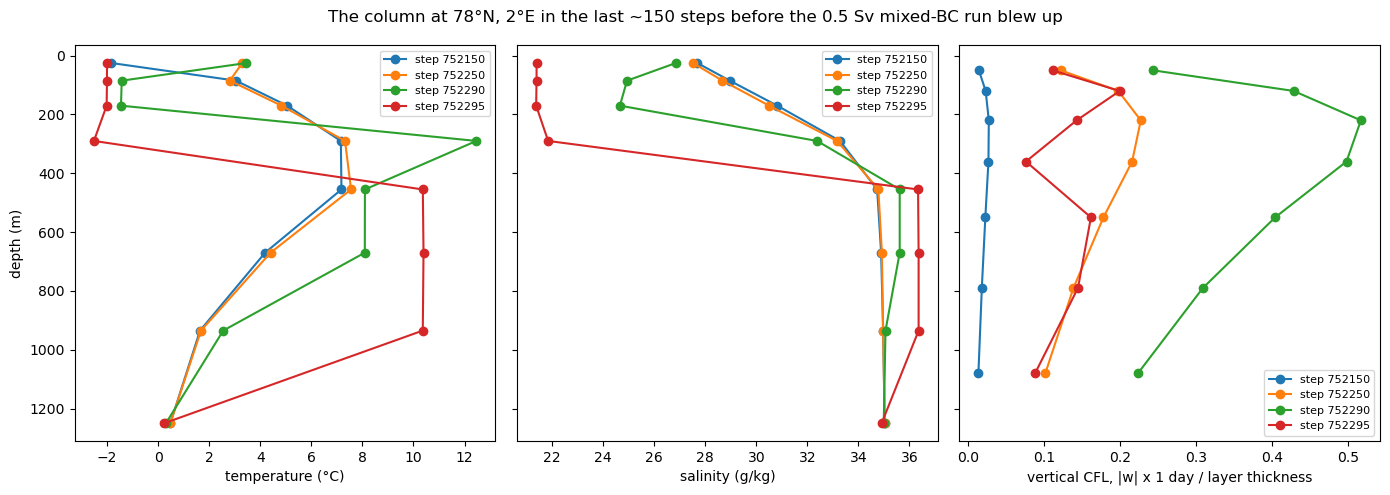

In [11]:
z_centre = np.cumsum(grid["drf"]) - grid["drf"] / 2
show_steps = [752150, 752250, 752290, 752295]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for it in show_steps:
    t = rdmds(os.path.join(DIAG, "T"), it)[:, j0, i0]
    s = rdmds(os.path.join(DIAG, "S"), it)[:, j0, i0]
    w = rdmds(os.path.join(DIAG, "W"), it)[:, j0, i0]
    cfl = np.abs(w[1:]) * 86400.0 / grid["drf"][:-1]     # w at the top of level k+1, across level k
    axes[0].plot(t[:8], z_centre[:8], "o-", label=f"step {it}")
    axes[1].plot(s[:8], z_centre[:8], "o-", label=f"step {it}")
    axes[2].plot(cfl[:7], grid["z_interface"][1:8], "o-", label=f"step {it}")
    print(f"step {it}: largest local vertical CFL in the top 1500 m = {cfl[:7].max():.2f}")
axes[0].set_xlabel("temperature (°C)")
axes[1].set_xlabel("salinity (g/kg)")
axes[2].set_xlabel("vertical CFL, |w| x 1 day / layer thickness")
axes[0].set_ylabel("depth (m)")
axes[0].invert_yaxis()
for ax in axes:
    ax.legend(fontsize=8)
fig.suptitle("The column at 78°N, 2°E in the last ~150 steps before the 0.5 Sv mixed-BC run blew up")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_blowup_column.png"), dpi=150)
plt.show()

## Appendix B: integrity check of all runs

Because the 0.5 Sv run blew up silently, I check every run, not just that one. For each run I scan:

- the model log for NaN;
- every output file for non-finite values;
- the yearly minimum and maximum of temperature and salinity from the monitor;
- temperatures below the local freezing point.

For the freezing point I use the UNESCO formula (Millero 1978), Tf = -0.0575 S + 1.710523e-3 S^1.5 - 2.154996e-4 S^2 - 7.53e-4 p (p in dbar, about the depth in m). With `allowFreezing`, the model only stops the surface from going below a fixed -1.9 °C, whatever the salinity. Fresher water freezes at a higher temperature, so a fresh surface layer can sit slightly below its own freezing point in this model. That is a limit of the model's simple sea-ice treatment, not a numerical error, and I report it rather than treat it as a failure.

In [12]:
import re
import glob as globmod

def freezing_point(salt, pressure_dbar):
    return -0.0575 * salt + 1.710523e-3 * np.abs(salt) ** 1.5 - 2.154996e-4 * salt ** 2 - 7.53e-4 * pressure_dbar

ocean3d = grid["hfacc"] > 0
z_centre = np.cumsum(grid["drf"]) - grid["drf"] / 2
check_runs = (["spinup", "restore_control"]
              + [f"restore_hose{c}_{p}" for c in HOSING for p in ["on", "off"]]
              + ["mixed_control"]
              + [f"mixed_hose{c}_{p}" for c in HOSING for p in ["on", "off"]])

rows = []
for run in check_runs:
    d = os.path.join(RUNS, run)
    text = open(os.path.join(d, "output.txt")).read()
    nan_lines = len(re.findall(r"\bNaN\b", text))
    def monitor(name):
        return np.array([float(v) for v in re.findall(r"%MON " + name + r"\s+=\s+(\S+)", text)])
    tmin, tmax = monitor("dynstat_theta_min"), monitor("dynstat_theta_max")
    smin, smax = monitor("dynstat_salt_min"), monitor("dynstat_salt_max")
    ok = np.isfinite(tmin) & np.isfinite(tmax)
    # every output file (not links, not pickups) scanned for non-finite values
    n_files = 0
    n_bad = 0
    for f in globmod.glob(os.path.join(d, "*.data")):
        if os.path.islink(f) or os.path.basename(f).startswith("pickup"):
            continue
        n_files += 1
        if not np.all(np.isfinite(np.fromfile(f, dtype=">f4"))):
            n_bad += 1
    # freezing check: annual surface fields (top level, 25 m) and 10-year 3D means
    worst_surface = np.inf
    worst_cells = 0
    for it in output_iterations(d, "surf_ts_annual"):
        sst = annual_field(d, "surf_ts_annual", "THETA", it)
        sss = annual_field(d, "surf_ts_annual", "SALT", it)
        if not np.all(np.isfinite(sst[grid["ocean"]])):
            continue
        below = (sst - freezing_point(sss, z_centre[0]))[grid["ocean"]]
        worst_surface = min(worst_surface, below.min())
        worst_cells = max(worst_cells, int(np.sum(below < -0.1)))
    worst_3d = np.inf
    for it in output_iterations(d, "state_decadal"):
        t3 = annual_field(d, "state_decadal", "THETA", it)
        s3 = annual_field(d, "state_decadal", "SALT", it)
        if not np.all(np.isfinite(t3[ocean3d])):
            continue
        worst_3d = min(worst_3d, (t3 - freezing_point(s3, z_centre[:, None, None]))[ocean3d].min())
    rows.append((run, len(tmin), nan_lines, n_bad, n_files,
                 tmin[ok].min() if ok.any() else np.nan, tmax[ok].max() if ok.any() else np.nan,
                 smin[ok].min() if ok.any() else np.nan, smax[ok].max() if ok.any() else np.nan,
                 worst_surface if np.isfinite(worst_surface) else np.nan, worst_cells,
                 worst_3d if np.isfinite(worst_3d) else np.nan))   # nan = no finite fields to check

print(f"{'run':20s} {'monitor':>7s} {'NaN in':>6s} {'bad files':>10s} {'T min':>6s} {'T max':>6s} {'S min':>6s} {'S max':>6s} "
      f"{'surface T-Tf':>13s} {'cells < -0.1':>12s} {'3D T-Tf':>8s}")
for r in rows:
    print(f"{r[0]:20s} {r[1]:7d} {r[2]:6d} {r[3]:4d}/{r[4]:<5d} {r[5]:6.2f} {r[6]:6.2f} {r[7]:6.2f} {r[8]:6.2f} "
          f"{r[9]:13.2f} {r[10]:12d} {r[11]:8.2f}")
print("(monitor = number of monitor blocks; T, S ranges are over the finite monitor values; "
      "surface T-Tf is the lowest annual-mean surface temperature minus its freezing point; "
      "cells < -0.1 is the largest number of surface cells more than 0.1 °C below freezing in any year; "
      "3D T-Tf is the same for the 10-year 3D means; nan = no finite values to check)")

run                  monitor NaN in  bad files  T min  T max  S min  S max  surface T-Tf cells < -0.1  3D T-Tf
spinup                  2001      0    0/6263   -1.97  30.44  29.74  37.53          0.36            0    -0.17
restore_control          501      0    0/1598   -1.97  30.42  29.74  37.51          0.49            0     0.49
restore_hose010_on       201      0    0/665    -1.97  30.42  29.74  37.51          0.49            0     0.49
restore_hose010_off      301      0    0/976    -1.97  30.42  29.74  37.50          0.50            0     0.50
restore_hose030_on       201      0    0/665    -1.97  30.42  29.74  37.51          0.49            0     0.49
restore_hose030_off      301      0    0/976    -1.97  30.42  29.74  37.51          0.51            0     0.51
restore_hose050_on       201      0    0/665    -1.97  30.42  29.74  37.52          0.49            0     0.47
restore_hose050_off      301      0    0/976    -1.97  30.42  29.74  37.51          0.51            0     0.51
m

## Appendix C: early warning signs in the 0.5 Sv run?

I compare the 0.5 Sv run's yearly monitor output with the healthy 0.3 Sv run over 2001-2089, plus the annual surface salinity of the column at 78°N, 2°E where the instability started.

0.3 Sv, year 2089: largest w 2.09e-05 m/s, lowest salinity 26.56 g/kg, surface salinity at 78°N 2°E 29.22 g/kg


0.5 Sv, year 2089: largest w 2.09e-05 m/s, lowest salinity 23.49 g/kg, surface salinity at 78°N 2°E 27.63 g/kg


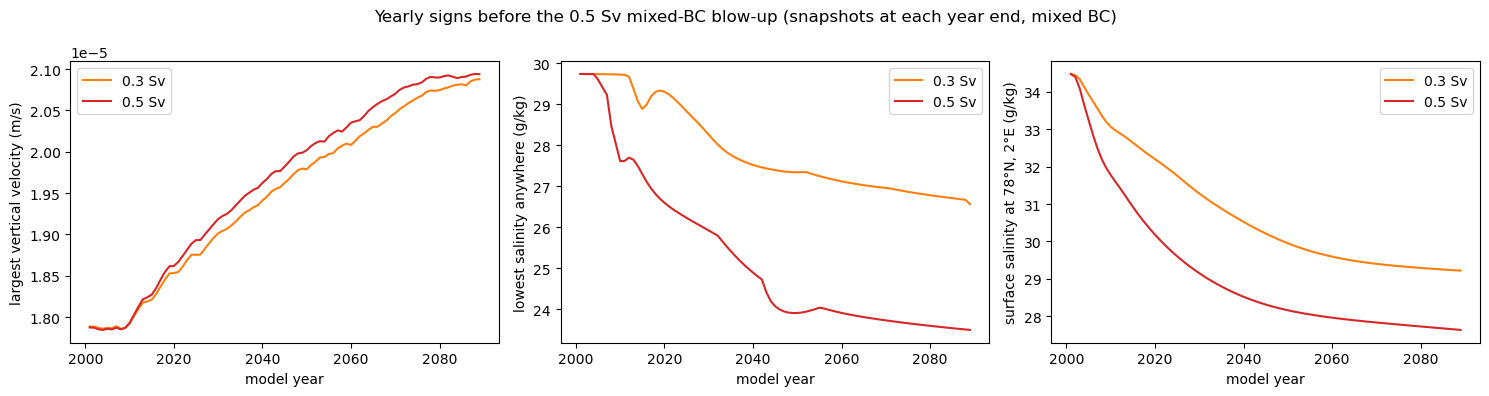

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for code in ["030", "050"]:
    text = open(os.path.join(RUNS, f"mixed_hose{code}_on", "output.txt")).read()
    w_max = np.array([float(v) for v in re.findall(r"%MON dynstat_wvel_max\s+=\s+(\S+)", text)])[1:90]
    s_min = np.array([float(v) for v in re.findall(r"%MON dynstat_salt_min\s+=\s+(\S+)", text)])[1:90]
    its = [720000 + STEPS_PER_YEAR * k for k in range(1, 90)]
    column_s = [annual_field(os.path.join(RUNS, f"mixed_hose{code}_on"), "surf_ts_annual", "SALT", it)[j0, i0] for it in its]
    yrs = 2000 + np.arange(1, 90)
    axes[0].plot(yrs, w_max, color=COLORS[code], label=f"{HOSING[code]} Sv")
    axes[1].plot(yrs, s_min, color=COLORS[code], label=f"{HOSING[code]} Sv")
    axes[2].plot(yrs, column_s, color=COLORS[code], label=f"{HOSING[code]} Sv")
    print(f"{HOSING[code]} Sv, year 2089: largest w {w_max[-1]:.2e} m/s, lowest salinity {s_min[-1]:.2f} g/kg, "
          f"surface salinity at 78°N 2°E {column_s[-1]:.2f} g/kg")
axes[0].set_ylabel("largest vertical velocity (m/s)")
axes[1].set_ylabel("lowest salinity anywhere (g/kg)")
axes[2].set_ylabel("surface salinity at 78°N, 2°E (g/kg)")
for ax in axes:
    ax.set_xlabel("model year")
    ax.legend()
fig.suptitle("Yearly signs before the 0.5 Sv mixed-BC blow-up (snapshots at each year end, mixed BC)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_early_warning_check.png"), dpi=150)
plt.show()

## Appendix D: sensitivity test of the advection scheme

To test my reading of the failure, I restarted from a clean state and changed only the tracer advection scheme (`experiments/sensitivity_hose050/`):

- Stage 0 reran the 0.5 Sv mixed-BC run from year 2000 to the end of model year 2088 (step 751680), about 620 steps before the instability, and saved that state.
- `orig` restarted from it with the original scheme (centred second order, scheme 2).
- `fluxlim` restarted from it with a flux-limited, monotonic scheme (`tempAdvScheme = saltAdvScheme = 33`, third-order DST with a flux limiter). Nothing else changed.

All three used a build where the bounds check also stops on NaN (`experiments/safety_code/mon_solution.F`), with the check run every model month.

In [14]:
SENS = {name: os.path.join(RUNS, f"sens050_{name}") for name in ["orig", "fluxlim"]}

def solver_values(path):
    values = []
    for line in open(path):
        if line.startswith(" cg2d: Sum(rhs),rhsMax"):
            values.append(line.split()[-1])
    return values

# 1. Does the original scheme reproduce the blow-up exactly? Compare the solver's rhsMax step by step.
original_run = solver_values(os.path.join(RUNS, "mixed_hose050_on", "output.txt"))
rerun = solver_values(os.path.join(SENS["orig"], "output.txt"))
offset = 751680 - 720000                                   # the rerun starts 31680 steps later
same = sum(1 for n in range(len(rerun)) if rerun[n] == original_run[offset + n])
print(f"orig: {same} of {len(rerun)} solver values identical to the original run, step by step")
stderr = open(os.path.join(SENS["orig"], "STDERR.0000")).read()
for line in stderr.splitlines():
    if "OUT OF BOUNDS" in line or "STOPPING" in line:
        print("orig:", line.split(")", 1)[1].strip())

# 2. Did the flux-limited run stay healthy?
text = open(os.path.join(SENS["fluxlim"], "output.txt")).read()
tmin = np.array([float(v) for v in re.findall(r"%MON dynstat_theta_min\s+=\s+(\S+)", text)])
tmax = np.array([float(v) for v in re.findall(r"%MON dynstat_theta_max\s+=\s+(\S+)", text)])
smin = np.array([float(v) for v in re.findall(r"%MON dynstat_salt_min\s+=\s+(\S+)", text)])
print(f"fluxlim: ended normally: {'Execution ended Normally' in text} | NaN in log: {len(re.findall(r'NaN', text))} | "
      f"monthly monitor blocks: {len(tmin)} | T {tmin.min():.2f} to {tmax.max():.2f} °C | lowest S {smin.min():.2f} g/kg")

orig: 630 of 630 solver values identical to the original run, step by step
orig: SOLUTION IS HEADING OUT OF BOUNDS: tMin,tMax=        NaN        NaN
orig: MON_SOLUTION: STOPPING CALCULATION at Iter=    752310
fluxlim: ended normally: True | NaN in log: 0 | monthly monitor blocks: 1345 | T -1.98 to 30.42 °C | lowest S 23.00 g/kg


I compare the AMOC index of the flux-limited run with the original 0.5 Sv run (valid until 2089) and the 0.3 Sv run. This run uses different numerics from 2089 on, so it stays out of the comparison tables.

fluxlim: 112 annual means, years 2089-2200; AMOC index min -0.23 Sv, max -0.11 Sv, mean of the last 10 years -0.23 Sv
fluxlim: surface salinity at 78°N, 2°E from 27.66 (first year) to 26.95 g/kg (year 2200)


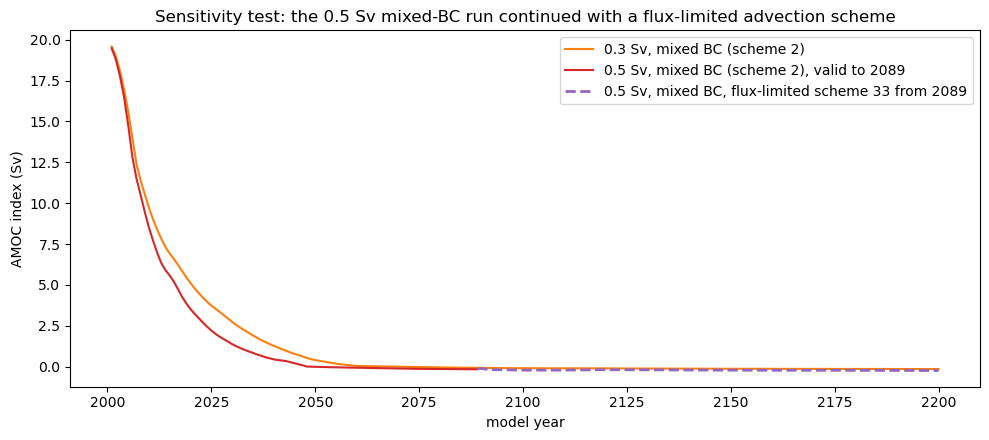

In [15]:
years_f, amoc_f = amoc_series([SENS["fluxlim"]], grid)
print(f"fluxlim: {len(years_f)} annual means, years {years_f[0]:.0f}-{years_f[-1]:.0f}; "
      f"AMOC index min {amoc_f.min():.2f} Sv, max {amoc_f.max():.2f} Sv, mean of the last 10 years {amoc_f[-10:].mean():.2f} Sv")
column_s = [annual_field(SENS["fluxlim"], "surf_ts_annual", "SALT", it)[j0, i0]
            for it in output_iterations(SENS["fluxlim"], "surf_ts_annual")]
print(f"fluxlim: surface salinity at 78°N, 2°E from {column_s[0]:.2f} (first year) to {column_s[-1]:.2f} g/kg (year 2200)")

fig, ax = plt.subplots(figsize=(10, 4.5))
hosing_years = years <= HOSING_END
ax.plot(years[hosing_years], mixed["030"][hosing_years], color=COLORS["030"], label="0.3 Sv, mixed BC (scheme 2)")
ax.plot(years[hosing_years], mixed["050"][hosing_years], color=COLORS["050"], label="0.5 Sv, mixed BC (scheme 2), valid to 2089")
ax.plot(years_f, amoc_f, color="tab:purple", lw=2, ls="--", label="0.5 Sv, mixed BC, flux-limited scheme 33 from 2089")
ax.set_xlabel("model year")
ax.set_ylabel("AMOC index (Sv)")
ax.set_title("Sensitivity test: the 0.5 Sv mixed-BC run continued with a flux-limited advection scheme")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "06_sensitivity_fluxlim.png"), dpi=150)
plt.show()